# Breast Cancer Classification

Acest proiect analizeaza un dataset medical pentru a prezice daca o tumora este benigna sau maligna folosind machine learning.

## Descrierea datasetului

Datasetul folosit este Breast Cancer Diagnosis Dataset, preluat de pe Kaggle.

Tipul problemei este clasificare binara, iar variabila tinta este "diagnosis", unde:
- B = benign
- M = malign

Datasetul contine 1200 exemple si 22 coloane. Majoritatea caracteristicilor sunt numerice si descriu proprietati morfologice ale tumorilor, precum radius, texture, perimeter, area, concavity si symmetry.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Vizualizare date

Afisez primele randuri din dataset pentru a intelege structura datelor.

In [23]:
df = pd.read_csv("Breast_cancer_Reseach.csv")
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,perimeter_se,area_se,smoothness_se,radius_worst,texture_worst,perimeter_worst,area_worst,concavity_worst,concave_points_worst,diagnosis
0,15.490142,19.500898,75.565249,526.409677,0.110140,0.094296,0.211172,0.109355,0.114075,0.054322,...,2.462022,42.305337,0.011282,18.287341,22.645848,101.643449,980.949501,0.300743,0.116431,B
1,13.585207,17.282378,93.536417,542.133582,0.098852,0.118453,0.205202,0.146600,0.218061,0.065125,...,1.592161,32.253159,0.007029,13.874569,27.706897,120.003792,734.421427,0.292429,0.114310,B
2,15.943066,19.489190,79.066398,957.471814,0.072091,0.102897,0.265062,0.125013,0.185707,0.062901,...,3.109572,61.427110,0.007098,19.765426,23.100544,165.333024,865.634991,0.138234,0.221270,B
3,18.569090,21.173192,84.566898,650.102423,0.085842,0.122600,0.132492,0.093229,0.168611,0.060439,...,3.020457,54.395979,0.005667,14.638553,25.579304,101.911156,808.195350,0.218719,0.243221,M
4,13.297540,19.195440,123.469042,767.319500,0.094745,0.139292,0.060506,0.154095,0.205715,0.069305,...,2.027102,32.581794,0.007993,19.998220,25.872578,89.016818,987.071625,0.520519,0.103556,M


## Structura datasetului

In aceasta etapa verific structura generala a datasetului: dimensiunea, numele coloanelor si tipurile de date.

In [24]:
df.shape

(1200, 22)

In [25]:
df.columns

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
       'concavity_worst', 'concave_points_worst', 'diagnosis'],
      dtype='str')

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   radius_mean             1200 non-null   float64
 1   texture_mean            1200 non-null   float64
 2   perimeter_mean          1200 non-null   float64
 3   area_mean               1200 non-null   float64
 4   smoothness_mean         1200 non-null   float64
 5   compactness_mean        1200 non-null   float64
 6   concavity_mean          1200 non-null   float64
 7   concave_points_mean     1200 non-null   float64
 8   symmetry_mean           1200 non-null   float64
 9   fractal_dimension_mean  1200 non-null   float64
 10  radius_se               1200 non-null   float64
 11  texture_se              1200 non-null   float64
 12  perimeter_se            1200 non-null   float64
 13  area_se                 1200 non-null   float64
 14  smoothness_se           1200 non-null   float64
 15

Observam ca datasetul are 1200 randuri si 22 coloane. 21 coloane sunt numerice, iar "diagnosis" este coloana categoriala folosita drept target. Nu apar valori lipsa.

## Distributia variabilei target

Verific distributia claselor pentru a observa daca exista dezechilibru intre cazurile benigne si maligne.

In [27]:
df['diagnosis'].value_counts()

diagnosis
B    612
M    588
Name: count, dtype: int64

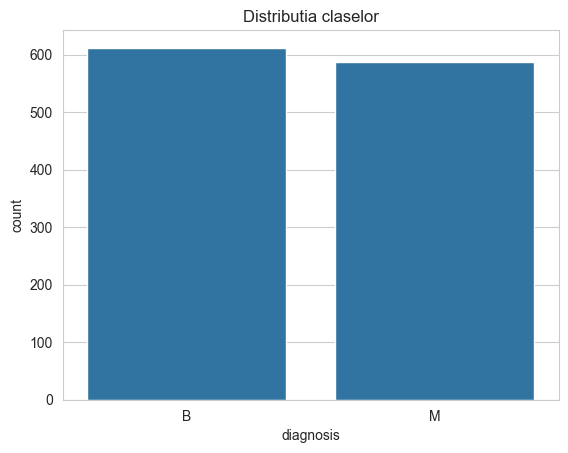

In [28]:
sns.countplot(x='diagnosis', data=df)
plt.title("Distributia claselor")
plt.show()

Se observa ca cele doua clase sunt relativ echilibrate. Acest lucru este favorabil pentru modelele de clasificare, deoarece reduce riscul ca modelul sa fie biased catre o singura clasa.

## Statistici descriptive

Analizez principalele statistici pentru variabilele numerice: media, deviatia standard, valorile minime, maxime si quartilele.

In [29]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_se,perimeter_se,area_se,smoothness_se,radius_worst,texture_worst,perimeter_worst,area_worst,concavity_worst,concave_points_worst
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,...,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,14.115147,19.098607,90.335292,640.950115,0.099299,0.148799,0.201459,0.100488,0.179238,0.059742,...,1.213701,2.496543,40.264451,0.007076,17.014271,25.034807,114.743920,893.602332,0.299746,0.148366
std,2.965186,3.934987,20.461030,147.792804,0.020181,0.051435,0.084157,0.038758,0.029412,0.009932,...,0.306748,0.711911,9.988414,0.002005,4.003028,5.071063,24.809778,199.025670,0.097025,0.047029
min,4.276198,6.921951,30.177281,173.494428,0.042010,-0.011051,-0.106932,-0.009812,0.062328,0.026244,...,0.275231,-0.044640,10.662294,0.001009,3.656394,5.718123,34.676160,168.982697,0.021271,-0.024752
25%,12.124986,16.432021,75.858482,543.449742,0.086126,0.112610,0.145663,0.074918,0.159386,0.053341,...,1.006448,2.034048,33.166113,0.005726,14.308360,21.668211,97.895249,754.403148,0.230088,0.117136
50%,14.144910,19.049251,90.340200,646.656555,0.099271,0.147930,0.199764,0.100693,0.179939,0.059528,...,1.216628,2.511138,40.172017,0.007126,16.864707,25.066549,114.797095,890.130444,0.299530,0.150011
75%,16.028042,21.690582,103.855434,738.880932,0.112667,0.185128,0.258915,0.126561,0.198811,0.066100,...,1.420914,2.972244,47.267903,0.008414,19.810665,28.564804,131.498222,1028.572872,0.366420,0.180218
max,25.558194,31.772430,168.524754,1136.463945,0.162258,0.326453,0.470191,0.226311,0.267423,0.093778,...,2.228673,4.698296,84.790843,0.013193,32.769324,43.014161,177.841087,1622.270013,0.613669,0.301914


Se observa diferente mari de scala intre variabile, de exemplu intre "smoothness_mean" si "area_mean". Acest lucru sugereaza ca in etapa de preprocessing va fi necesara standardizarea datelor.

## Analiza valorilor lipsa

Verific daca exista valori lipsa si daca este necesara imputarea sau eliminarea unor exemple.

In [30]:
df.isnull().sum()

radius_mean               0
texture_mean              0
perimeter_mean            0
area_mean                 0
smoothness_mean           0
compactness_mean          0
concavity_mean            0
concave_points_mean       0
symmetry_mean             0
fractal_dimension_mean    0
radius_se                 0
texture_se                0
perimeter_se              0
area_se                   0
smoothness_se             0
radius_worst              0
texture_worst             0
perimeter_worst           0
area_worst                0
concavity_worst           0
concave_points_worst      0
diagnosis                 0
dtype: int64

Datasetul nu contine valori lipsa, deci nu este necesara imputarea in aceasta etapa.

## Distributii si outlieri

In aceasta sectiune analizez distributia unor caracteristici numerice si verific prezenta valorilor extreme.

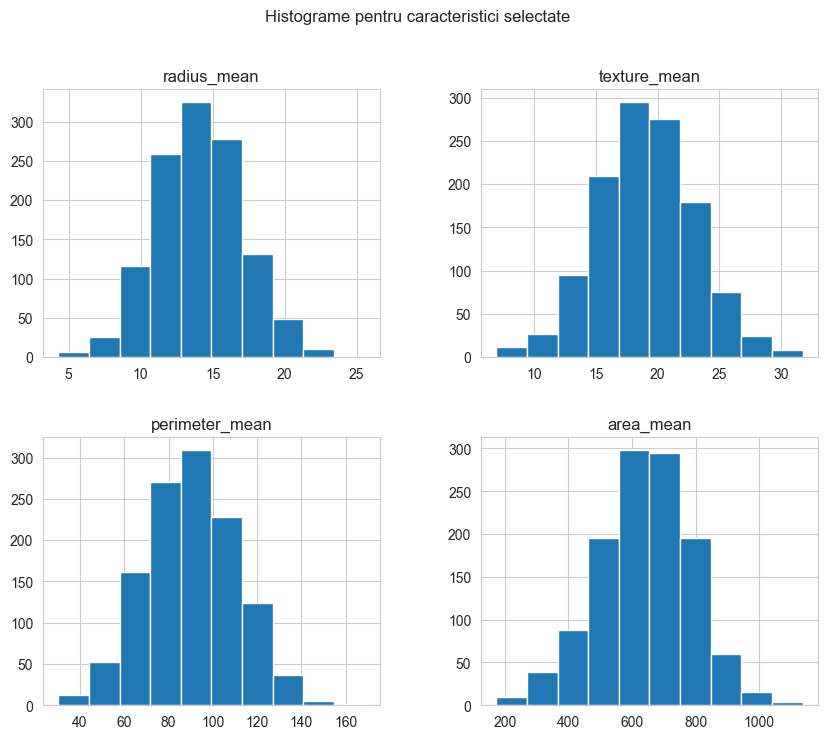

In [31]:
features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']

df[features].hist(figsize=(10, 8))
plt.suptitle("Histograme pentru caracteristici selectate")
plt.show()

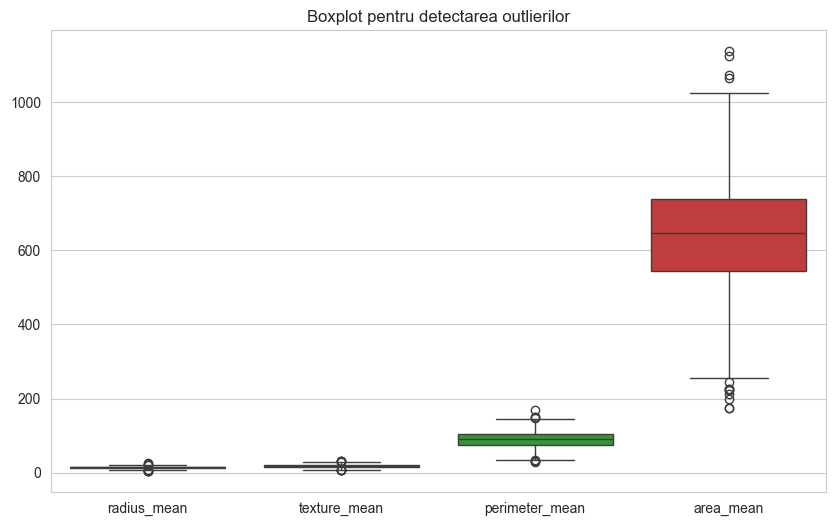

In [32]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']])
plt.title("Boxplot pentru detectarea outlierilor")
plt.show()

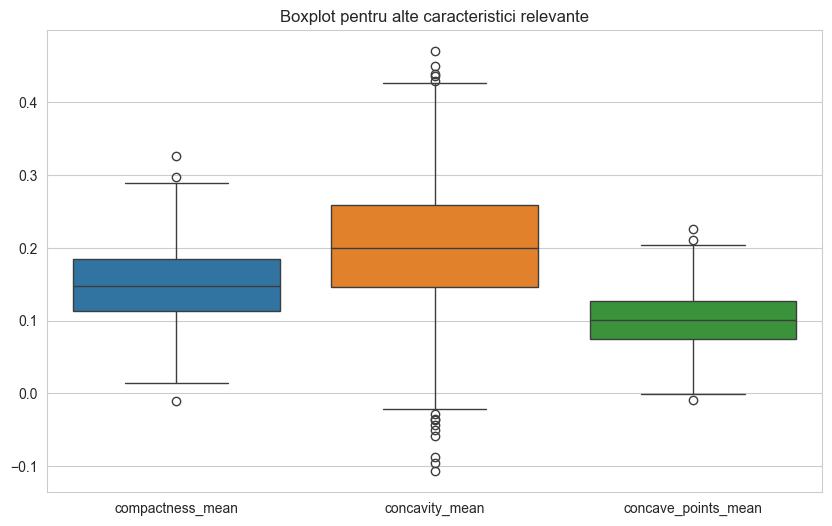

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['compactness_mean', 'concavity_mean', 'concave_points_mean']])
plt.title("Boxplot pentru alte caracteristici relevante")
plt.show()

Histogramele arata forma distributiilor pentru variabilele selectate, iar boxplot-urile evidentiaza prezenta unor valori extreme. Aceste observatii sunt importante pentru etapa de preprocessing si pentru alegerea modelelor.

## Analiza corelatiilor

Analizez corelatiile dintre variabilele numerice pentru a identifica relatii puternice intre caracteristici.

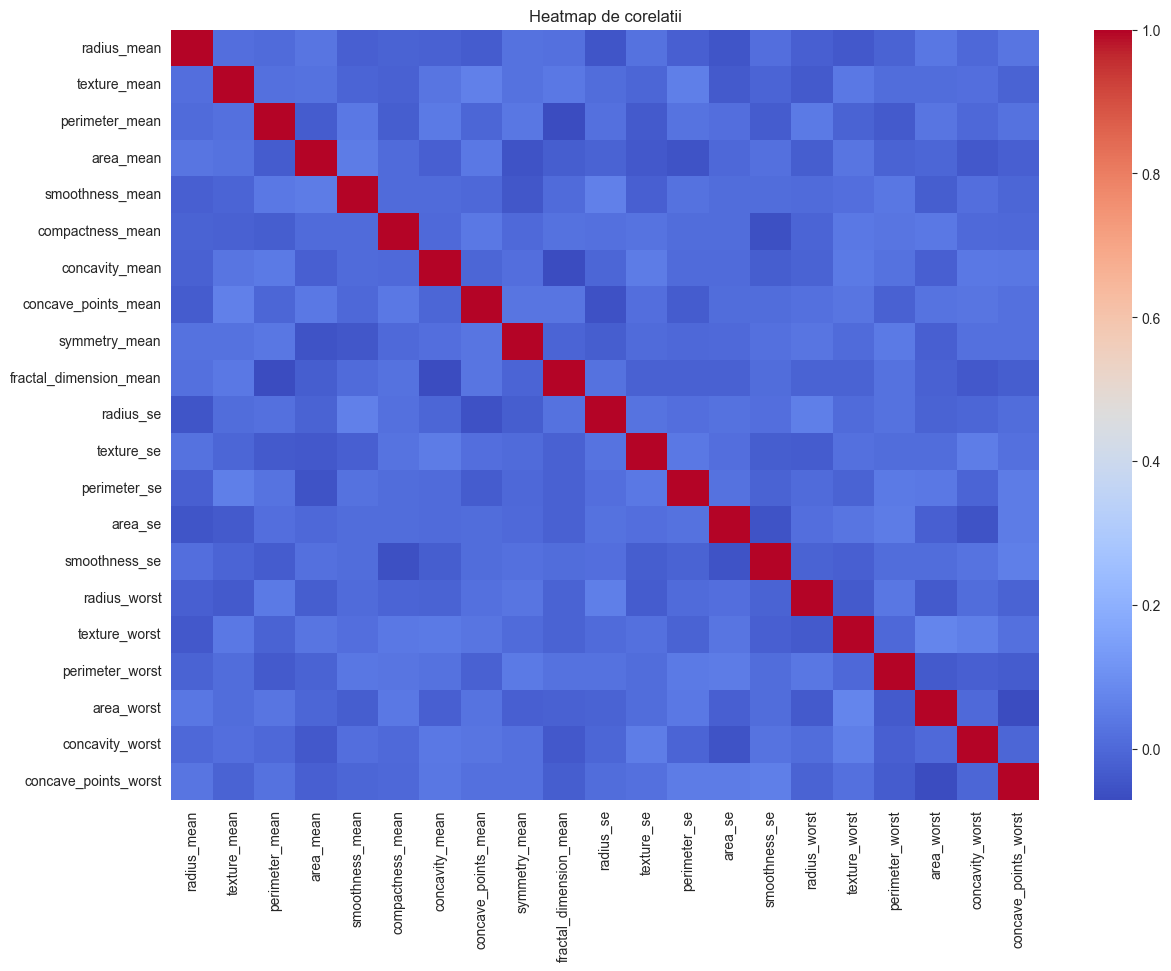

In [35]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title("Heatmap de corelatii")
plt.show()

Se observa corelatii puternice intre variabile precum "radius_mean", "perimeter_mean" si "area_mean", ceea ce indica faptul ca unele caracteristici transporta informatie similara. Acest lucru poate fi util ulterior in interpretare sau selectie de feature-uri.

## Concluzii

Datasetul ales este potrivit pentru o problema de clasificare binara. Variabila target este "diagnosis", iar clasele sunt relativ echilibrate. Nu exista valori lipsa, ceea ce simplifica etapa de preprocesare. Analiza distributiilor si a boxplot-urilor sugereaza existenta unor outlieri pentru anumite caracteristici. Heatmap-ul de corelatii arata relatii puternice intre unele variabile, ceea ce sugereaza redundanta partiala. De asemenea, diferentele mari de scala intre caracteristici indica necesitatea standardizarii datelor in etapa urmatoare, D2.